In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
df=pd.read_csv("netflix.csv")

In [21]:
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [7]:
df.shape

(8790, 10)

In [9]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in'],
      dtype='object')

In [10]:
df.dtypes

show_id         object
type            object
title           object
director        object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
dtype: object

In [25]:
df["date_added"]=pd.to_datetime(df["date_added"])

In [26]:
df.head(2)

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."


In [28]:
df.duplicated().value_counts()

False    8790
Name: count, dtype: int64

In [29]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

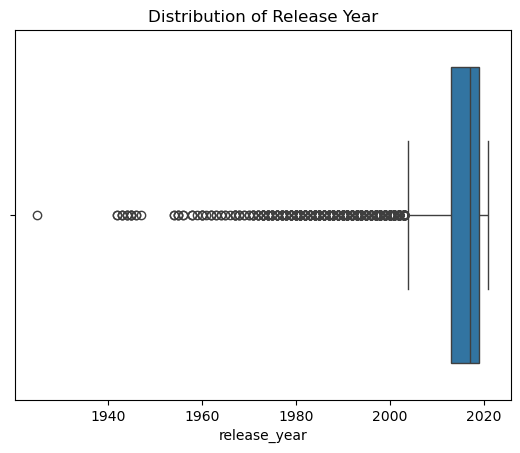

In [103]:
sns.boxplot(x=df['release_year'])
plt.title("Distribution of Release Year")
plt.show()

In [30]:
df.describe()

,date_added,release_year
count,8790,8790.000000
mean,2019-05-17 21:44:01.638225408,2014.183163
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-06 00:00:00,2013.000000
50%,2019-07-03 00:00:00,2017.000000
75%,2020-08-19 18:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.825466


In [33]:
df_types=df["type"].value_counts()
df_types.reset_index()

,type,count
0,Movie,6126
1,TV Show,2664


In [39]:
#Counting how many entries each director have
Ndirectors=df.groupby(['type','director'])["type"].value_counts().reset_index()
Ndirectors

,type,director,count
0,Movie,A. L. Vijay,2
1,Movie,A. Raajdheep,1
2,Movie,A. Salaam,1
3,Movie,A.R. Murugadoss,2
4,Movie,Aadish Keluskar,1
...,...,...,...
4576,TV Show,Vijay S. Bhanushali,1
4577,TV Show,"Vikramaditya Motwane, Anurag Kashyap",1
4578,TV Show,Wouter Bouvijn,1
4579,TV Show,Yasuhiro Irie,1


In [50]:
#number of top 10 TV show with each director
ttm10=Ndirectors[(Ndirectors['type']=='Movie') & (Ndirectors['director'] != 'Not Given')].sort_values(by='count',ascending=False).head(10)
ttm10

,type,director,count
3253,Movie,Rajiv Chilaka,19
3304,Movie,"Raúl Campos, Jan Suter",18
3886,Movie,Suhas Kadav,16
2492,Movie,Marcus Raboy,15
1716,Movie,Jay Karas,14
661,Movie,Cathy Garcia-Molina,13
2562,Movie,Martin Scorsese,12
1713,Movie,Jay Chapman,12
4307,Movie,Youssef Chahine,12
3863,Movie,Steven Spielberg,11


In [43]:
#number of top 10 TV show with each director
tts10 = Ndirectors[(Ndirectors['type']=='TV Show') & (Ndirectors['director'] != 'Not Given')].sort_values(by = 'count',ascending = False).head(10)
tts10

,type,director,count
4360,TV Show,Alastair Fothergill,14
4490,TV Show,"Mark Thornton, Todd Kauffman",5
4553,TV Show,Stan Lathan,3
4463,TV Show,Ken Burns,2
4546,TV Show,Shin Won-ho,2
4429,TV Show,Iginio Straffi,2
4427,TV Show,Hsu Fu-chun,2
4536,TV Show,Rob Seidenglanz,2
4517,TV Show,Padraic McKinley,1
4507,TV Show,Nopparoj Chotmunkongsit,1


In [53]:
df.country.nunique()

86

In [56]:
type_country=df.groupby('type')['country'].value_counts().reset_index()
type_country

,type,country,count
0,Movie,United States,2395
1,Movie,India,976
2,Movie,United Kingdom,387
3,Movie,Not Given,257
4,Movie,Canada,187
...,...,...,...
133,TV Show,Puerto Rico,1
134,TV Show,Senegal,1
135,TV Show,Switzerland,1
136,TV Show,United Arab Emirates,1


In [55]:
top_10_country=type_country.sort_values(by='count',ascending=False).head(10)
top_10_country

,type,country,count
0,Movie,United States,2395
1,Movie,India,976
79,TV Show,United States,845
2,Movie,United Kingdom,387
80,TV Show,Pakistan,350
3,Movie,Not Given,257
81,TV Show,United Kingdom,251
4,Movie,Canada,187
82,TV Show,Japan,172
83,TV Show,South Korea,165


In [57]:
df['release_year'].nunique()

74

In [58]:
releaseyears=df.groupby('release_year')['release_year'].value_counts().reset_index()
releaseyears

,release_year,count
0,1925,1
1,1942,2
2,1943,3
3,1944,3
4,1945,4
...,...,...
69,2017,1030
70,2018,1146
71,2019,1030
72,2020,953


In [62]:
cmpy10 = releaseyears.sort_values(by = 'count' , ascending = False).head(10)
cmpy10

,release_year,count
70,2018,1146
71,2019,1030
69,2017,1030
72,2020,953
68,2016,901
73,2021,592
67,2015,555
66,2014,352
65,2013,286
64,2012,236


In [63]:
df['director'].value_counts()

director
Not Given                         2588
Rajiv Chilaka                       20
Alastair Fothergill                 18
Raúl Campos, Jan Suter              18
Suhas Kadav                         16
                                  ... 
Matt D'Avella                        1
Parthiban                            1
Scott McAboy                         1
Raymie Muzquiz, Stu Livingston       1
Mozez Singh                          1
Name: count, Length: 4528, dtype: int64

In [65]:
df=df.drop('director',axis=1)
df

,show_id,type,title,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,United States,2021-09-25,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
...,...,...,...,...,...,...,...,...,...
8785,s8797,TV Show,Yunus Emre,Turkey,2017-01-17,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas"
8786,s8798,TV Show,Zak Storm,United States,2018-09-13,2016,TV-Y7,3 Seasons,Kids' TV
8787,s8801,TV Show,Zindagi Gulzar Hai,Pakistan,2016-12-15,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ..."
8788,s8784,TV Show,Yoko,Pakistan,2018-06-23,2016,TV-Y,1 Season,Kids' TV


In [71]:
df.rename(columns={"listed_in":"genre"},inplace=True)

In [72]:
df.tail()

,show_id,type,title,country,date_added,release_year,rating,duration,genre
8785,s8797,TV Show,Yunus Emre,Turkey,2017-01-17,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas"
8786,s8798,TV Show,Zak Storm,United States,2018-09-13,2016,TV-Y7,3 Seasons,Kids' TV
8787,s8801,TV Show,Zindagi Gulzar Hai,Pakistan,2016-12-15,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ..."
8788,s8784,TV Show,Yoko,Pakistan,2018-06-23,2016,TV-Y,1 Season,Kids' TV
8789,s8786,TV Show,YOM,Pakistan,2018-06-07,2016,TV-Y7,1 Season,Kids' TV


In [74]:
#most common ratings
df['rating'].value_counts()

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [76]:
df.groupby('country')['type'].value_counts().reset_index()

,country,type,count
0,Argentina,Movie,56
1,Argentina,TV Show,20
2,Australia,Movie,61
3,Australia,TV Show,53
4,Austria,Movie,8
...,...,...,...
133,Uruguay,TV Show,1
134,Venezuela,Movie,2
135,Vietnam,Movie,7
136,West Germany,Movie,1


In [77]:
df[df['type']=='Movie']['duration'].max()

'99 min'

In [79]:
#Most 
df['genre'].value_counts().head(10).reset_index()

,genre,count
0,"Dramas, International Movies",362
1,Documentaries,359
2,Stand-Up Comedy,334
3,"Comedies, Dramas, International Movies",274
4,"Dramas, Independent Movies, International Movies",252
5,Kids' TV,219
6,Children & Family Movies,215
7,"Children & Family Movies, Comedies",201
8,"Documentaries, International Movies",186
9,"Dramas, International Movies, Romantic Movies",180


In [81]:
#Recent content
df[df['date_added'] == df['date_added'].max()]

,show_id,type,title,country,date_added,release_year,rating,duration,genre
0,s1,Movie,Dick Johnson Is Dead,United States,2021-09-25,2020,PG-13,90 min,Documentaries


In [88]:
#most common genre in TV shows
df[df['type']=='TV Show']['genre'].str.split(', ').explode().value_counts().head(1)

genre
International TV Shows    1349
Name: count, dtype: int64

In [89]:
#oldest movie
df[df['type']=='Movie'].sort_values(by='release_year').head(1)

,show_id,type,title,country,date_added,release_year,rating,duration,genre
5698,s7791,Movie,Prelude to War,United States,2017-03-31,1942,TV-14,52 min,"Classic Movies, Documentaries"


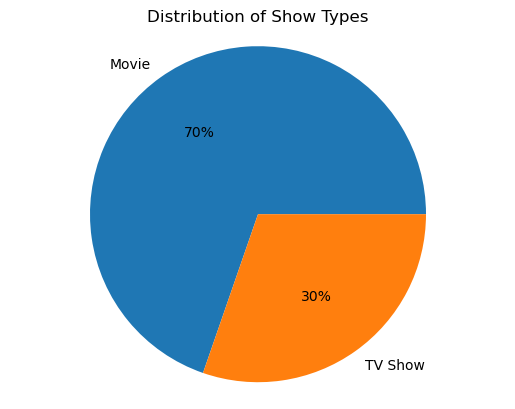

In [98]:
plt.pie(df_types, labels=df_types.index, autopct="%0.0f%%")
plt.title("Distribution of Show Types")
plt.axis("equal")
plt.show()

<Axes: title={'center': 'Top 10 Most Popular Genres on Netflix'}, xlabel='genre'>

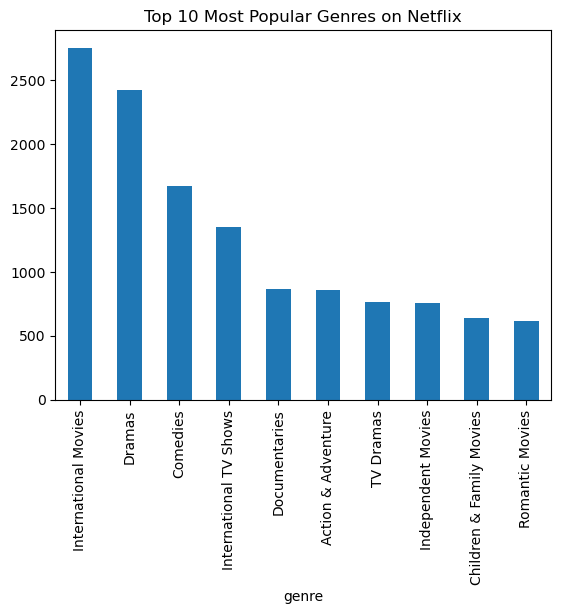

In [93]:
df['genre'].str.split(', ').explode().value_counts().head(10).plot(
    kind='bar',
    title='Top 10 Most Popular Genres on Netflix'
)

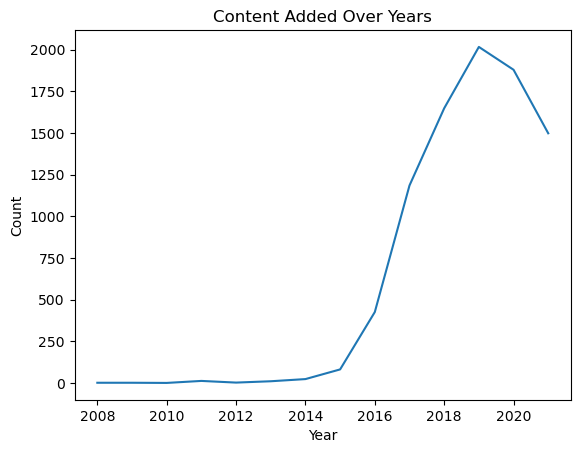

In [99]:
df['date_added'] = pd.to_datetime(df['date_added'])
df['year_added'] = df['date_added'].dt.year
year_counts = df['year_added'].value_counts().sort_index()
plt.plot(year_counts.index, year_counts.values)
plt.title("Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

<Axes: title={'center': 'Top 10 Countries Producing Netflix Content'}, xlabel='country'>

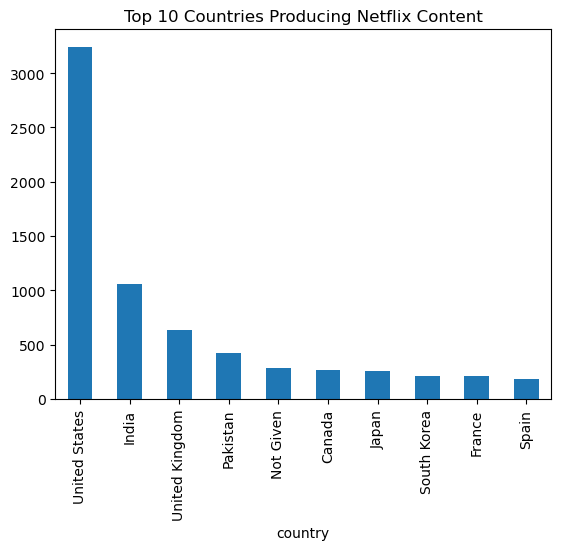

In [96]:
df['country'].value_counts().head(10).plot(
    kind='bar',
    title='Top 10 Countries Producing Netflix Content'
)

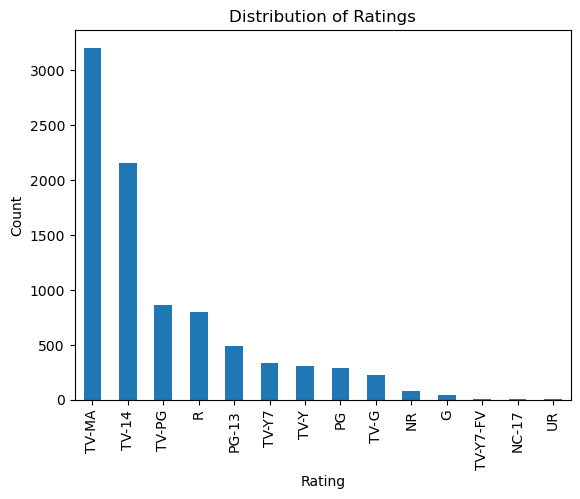

In [100]:
df['rating'].value_counts().plot(kind='bar')
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

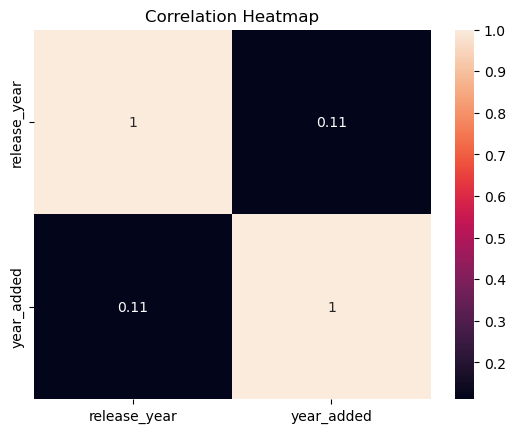

In [105]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()